In [1]:
# complete feature Engineering

In [2]:
import numpy as np
import pandas as pd


In [3]:
df = pd.read_csv("/content/Churn_Modelling.csv")

In [5]:
df.shape

(10000, 14)

In [8]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [33]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [11]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
numerical_col = ['CreditScore','Age','Tenure',"Balance","NumOfProducts","HasCrCard","IsActiveMember",
                "EstimatedSalary" ]

In [13]:
categorical_col = ['Geography',"Gender"]

In [14]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


In [15]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="median"
    )),

    ("scaler", StandardScaler())
])

In [16]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

In [17]:
preprocessor = ColumnTransformer([
    ("numerical", numeric_pipeline, numerical_col),
    ("categorical", categorical_pipeline, categorical_col)
])

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop("Exited", axis=1)
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [20]:
import pandas as pd

def outlier_summary(df, numerical_cols):
    result = []

    for col in numerical_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = ((df[col] < lower) | (df[col] > upper)).sum()

        result.append({
            "Feature": col,
            "Q1": Q1,
            "Q3": Q3,
            "Lower_Bound": lower,
            "Upper_Bound": upper,
            "Outliers": outliers,
            "Outlier_%": round((outliers / len(df)) * 100, 2)
        })

    return pd.DataFrame(result)


outlier_df = outlier_summary(df, numerical_col)

outlier_df

,Feature,Q1,Q3,Lower_Bound,Upper_Bound,Outliers,Outlier_%
0,CreditScore,584.00,718.0000,383.00000,919.00000,15,0.15
1,Age,32.00,44.0000,14.00000,62.00000,359,3.59
2,Tenure,3.00,7.0000,-3.00000,13.00000,0,0.00
3,Balance,0.00,127644.2400,-191466.36000,319110.60000,0,0.00
4,NumOfProducts,1.00,2.0000,-0.50000,3.50000,60,0.60
5,HasCrCard,0.00,1.0000,-1.50000,2.50000,0,0.00
6,IsActiveMember,0.00,1.0000,-1.50000,2.50000,0,0.00
7,EstimatedSalary,51002.11,149388.2475,-96577.09625,296967.45375,0,0.00


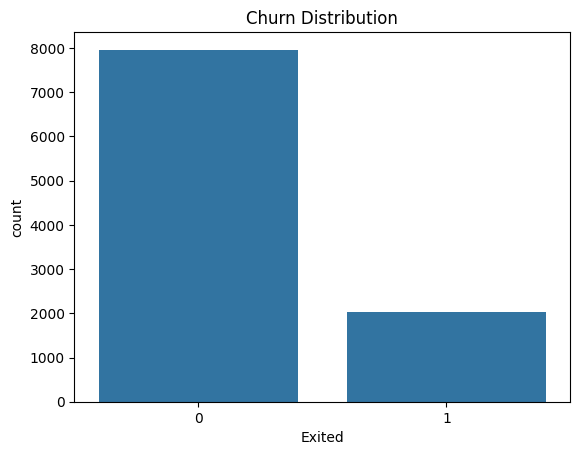

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Exited")
plt.title("Churn Distribution")
plt.show()


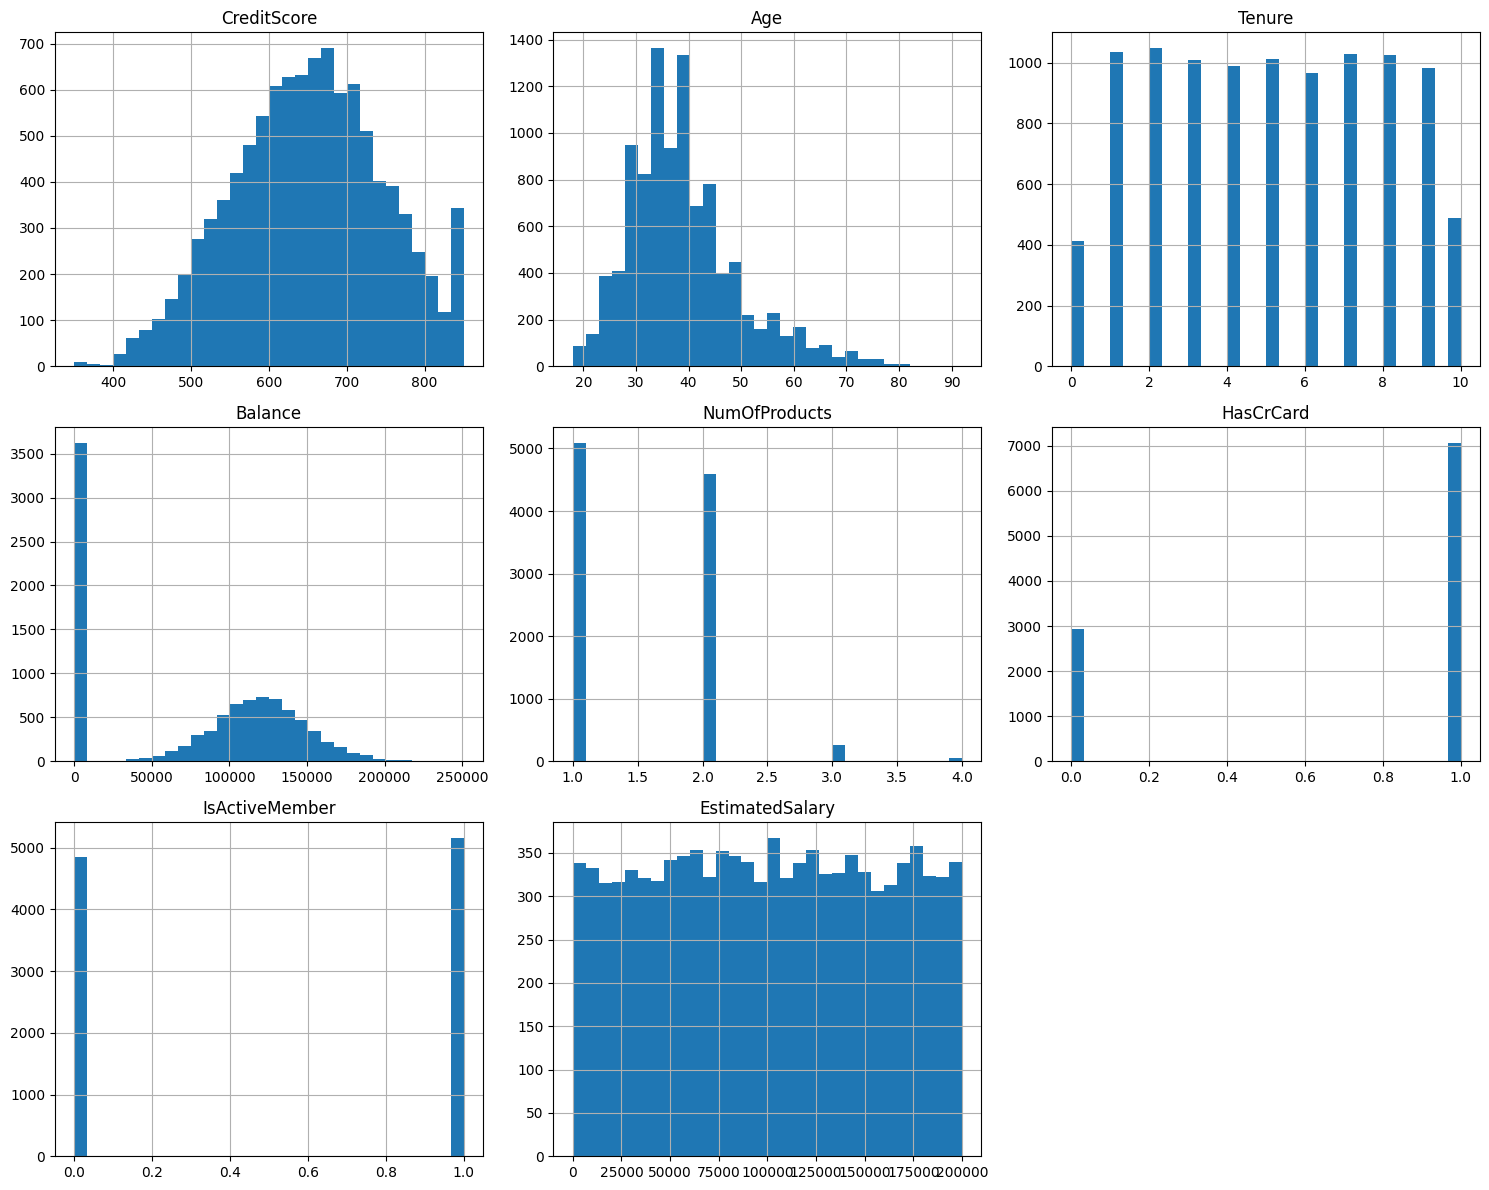

In [24]:
df[numerical_col].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

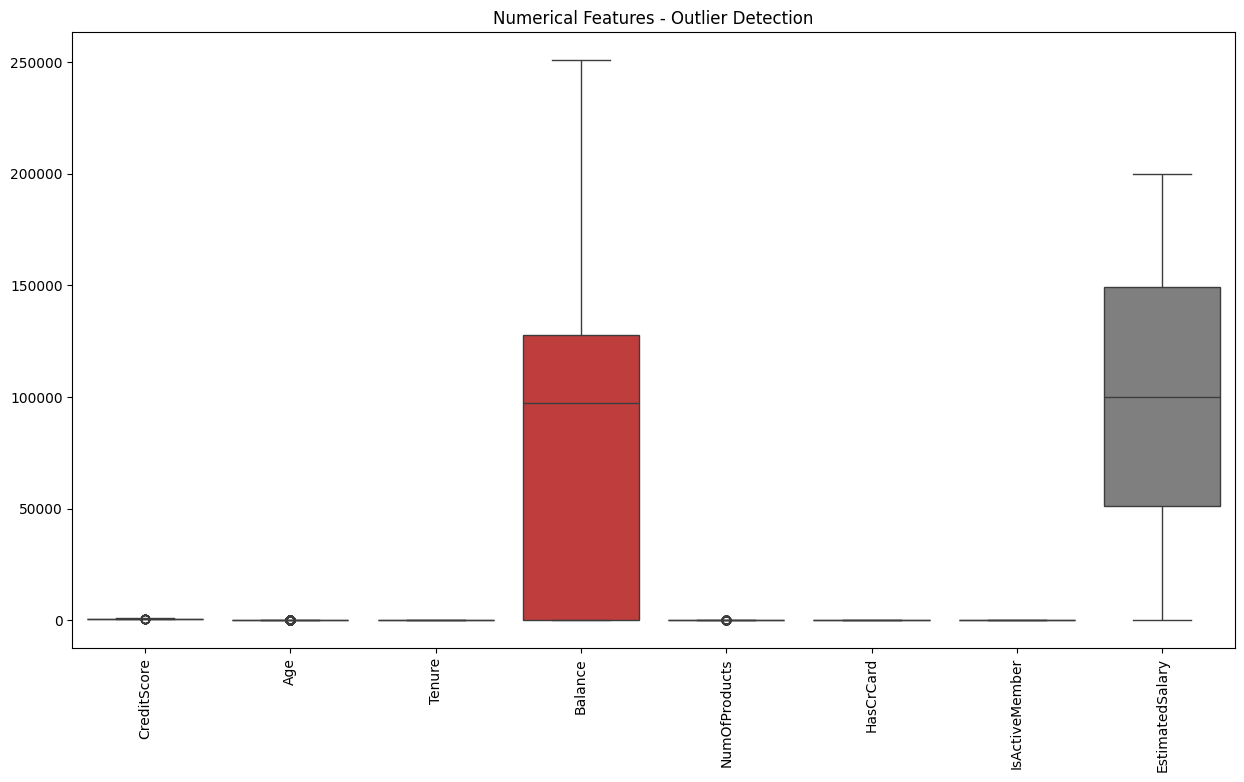

In [26]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df[numerical_col])

plt.xticks(rotation=90)
plt.title("Numerical Features - Outlier Detection")
plt.show()

In [27]:
# apply data machine learning model
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

In [28]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Geography', 'Gender'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [29]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [30]:
y_prob

array([0.31758131, 0.57657339, 0.34998918, ..., 0.88808251, 0.34743127,
       0.35411191])

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.7135
Precision: 0.38722826086956524
Recall   : 0.7002457002457002
F1 Score : 0.49868766404199477
ROC-AUC  : 0.7771654551315569


In [32]:
print(confusion_matrix(y_test, y_pred))

[[1142  451]
 [ 122  285]]
